In [ ]:
                                                    RMSprop Optimizer

In [ ]:
What is RMSProp :-
                     RMSprop Optimizer ek adaptive learning rate optimizer hai jo gradients ka square ko accumulate karta hai aur fir uske
                     cumulative average ko normalize karta hai. Yeh optimizer gradients ko stable rakhta hai aur convergence ko fast karta hai,
                     khas taur par non-stationary environments mein. RMSprop ka main fayda yeh hai ki yeh sparse data aur non-stationary data ke
                     liye kaafi effective hai.

RMSprop ka fayda:-
                  Yeh optimizer har parameter ke learning rate ko adjust karta hai based on recent gradients aur usko stabilize karta hai. 
                  Is optimizer ko mainly deep learning aur RNNs mein use kiya jata hai kyunki yeh fast convergence karta hai.

In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD,RMSprop,Adagrad
df = pd.read_csv(r"C:\Users\Lenovo\Desktop\gaurav\titanic.csv")
df =df.drop(columns=["Name","Ticket","Cabin"],axis=1)
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
df['Fare'].fillna(df['Fare'].median(), inplace=True)

# Features and target
X = df.drop('Survived', axis=1)
y = df['Survived']


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5288\3274466985.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5288\3274466985.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [14]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

array([[ 1.10264521, -0.31938196,  0.14282735, ...,  0.73911859,
        -0.35829929,  0.74883086],
       [-1.53115867, -0.31938196, -0.47466103, ...,  0.73911859,
        -0.35829929,  0.74883086],
       [-1.07348127, -0.31938196,  0.00949543, ...,  0.73911859,
         2.79096286, -1.33541504],
       ...,
       [ 0.53270732, -1.5046439 ,  1.22343202, ...,  0.73911859,
        -0.35829929, -1.33541504],
       [ 1.20627028, -0.31938196, -0.47466103, ...,  0.73911859,
        -0.35829929,  0.74883086],
       [-0.91804366,  0.86587998,  0.00949543, ...,  0.73911859,
         2.79096286, -1.33541504]])

In [16]:
def create_model():
    model = Sequential()
    model.add(Dense(32,input_dim=X_train.shape[1],activation="relu"))
    model.add(Dense(16,activation="relu"))
    model.add(Dense(1,activation="sigmoid"))
    return model
create_model()

C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<Sequential name=sequential, built=True>

In [46]:
model_momentam = create_model()
model_optimizers = SGD(learning_rate=0.01, momentum=0.9)
model_momentam.compile(optimizer=model_optimizers,loss='binary_crossentropy', metrics=['accuracy'])
history_momentam = model_momentam.fit(X_train,y_train,validation_data=(X_test, y_test), epochs=20, batch_size=32, verbose=1)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.5299 - loss: 0.6972 - val_accuracy: 0.6667 - val_loss: 0.6437
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7934 - loss: 0.5926 - val_accuracy: 0.8810 - val_loss: 0.5316
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9371 - loss: 0.4679 - val_accuracy: 0.9881 - val_loss: 0.3905
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9880 - loss: 0.3316 - val_accuracy: 1.0000 - val_loss: 0.2474
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9940 - loss: 0.2019 - val_accuracy: 1.0000 - val_loss: 0.1358
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9970 - loss: 0.1101 - val_accuracy: 1.0000 - val_loss: 0.0734
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9970 - loss: 0.0614 - val_accuracy: 1.0000 - val_loss: 0.0418
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.0370 - val_accuracy: 1.0000 - v

In [47]:
model_momentam = create_model()
model_optimizers = SGD(learning_rate=0.01, momentum=0.9,nesterov=True)
model_momentam.compile(optimizer=model_optimizers,loss='binary_crossentropy', metrics=['accuracy'])
history_nag = model_momentam.fit(X_train,y_train,validation_data=(X_test, y_test), epochs=20, batch_size=32, verbose=1)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.2635 - loss: 0.7658 - val_accuracy: 0.5714 - val_loss: 0.7223
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6437 - loss: 0.6599 - val_accuracy: 0.5952 - val_loss: 0.6442
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6497 - loss: 0.5834 - val_accuracy: 0.5952 - val_loss: 0.5817
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6796 - loss: 0.5118 - val_accuracy: 0.6786 - val_loss: 0.5069
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7964 - loss: 0.4249 - val_accuracy: 0.8810 - val_loss: 0.4106
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9341 - loss: 0.3237 - val_accuracy: 0.9643 - val_loss: 0.3018
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9760 - loss: 0.2221 - val_accuracy: 0.9881 - val_loss: 0.2005
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9970 - loss: 0.1391 - val_accuracy: 1.0000 - v

In [49]:
model_momentam = create_model()
model_optimizers = Adagrad(learning_rate=0.01)
model_momentam.compile(optimizer=model_optimizers,loss='binary_crossentropy', metrics=['accuracy'])
history_adagard = model_momentam.fit(X_train,y_train,validation_data=(X_test, y_test), epochs=20, batch_size=32, verbose=1)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.4341 - loss: 0.7289 - val_accuracy: 0.5595 - val_loss: 0.7014
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6168 - loss: 0.6935 - val_accuracy: 0.6667 - val_loss: 0.6731
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7246 - loss: 0.6643 - val_accuracy: 0.7619 - val_loss: 0.6475
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7635 - loss: 0.6384 - val_accuracy: 0.7738 - val_loss: 0.6248
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8323 - loss: 0.6132 - val_accuracy: 0.8690 - val_loss: 0.6026
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8832 - loss: 0.5883 - val_accuracy: 0.8810 - val_loss: 0.5799
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9042 - loss: 0.5632 - val_accuracy: 0.8810 - val_loss: 0.5560
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9251 - loss: 0.5371 - val_accuracy: 0.9048 - v

In [51]:
model_momentam = create_model()
model_optimizers = RMSprop(learning_rate=0.001)
model_momentam.compile(optimizer=model_optimizers,loss='binary_crossentropy', metrics=['accuracy'])
history_rmsprop = model_momentam.fit(X_train,y_train,validation_data=(X_test, y_test), epochs=20, batch_size=32, verbose=1)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.6886 - loss: 0.5486 - val_accuracy: 0.6667 - val_loss: 0.5279
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7904 - loss: 0.4564 - val_accuracy: 0.7381 - val_loss: 0.4633
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8593 - loss: 0.3905 - val_accuracy: 0.8333 - val_loss: 0.4012
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9251 - loss: 0.3314 - val_accuracy: 0.9167 - val_loss: 0.3468
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9641 - loss: 0.2791 - val_accuracy: 0.9405 - val_loss: 0.2955
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9701 - loss: 0.2315 - val_accuracy: 0.9643 - val_loss: 0.2475
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9910 - loss: 0.1892 - val_accuracy: 0.9762 - val_loss: 0.2035
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9970 - loss: 0.1531 - val_accuracy: 0.9762 - v

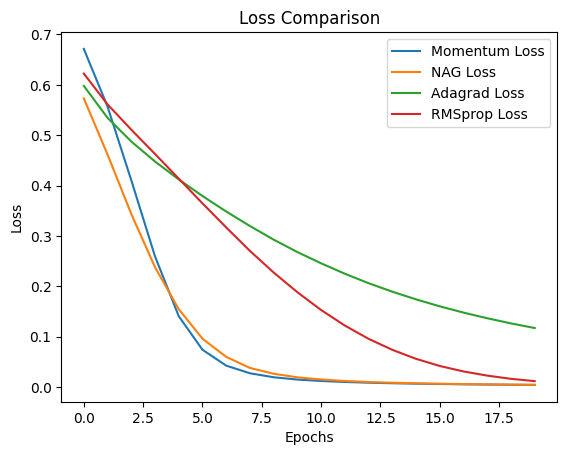

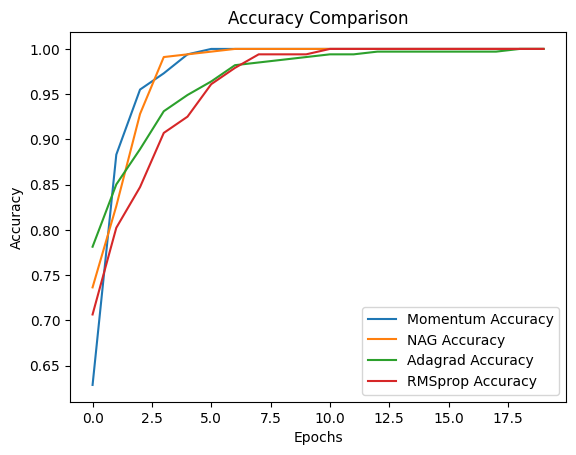

In [45]:
import matplotlib.pyplot as plt

# Loss comparison
plt.plot(history_momentam.history['loss'], label='Momentum Loss')
plt.plot(history_nag.history['loss'], label='NAG Loss')
plt.plot(history_adagard.history['loss'], label='Adagrad Loss')
plt.plot(history_rmsprop.history['loss'], label='RMSprop Loss')
plt.title('Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Accuracy comparison
plt.plot(history_momentam.history['accuracy'], label='Momentum Accuracy')
plt.plot(history_nag.history['accuracy'], label='NAG Accuracy')
plt.plot(history_adagard.history['accuracy'], label='Adagrad Accuracy')
plt.plot(history_rmsprop.history['accuracy'], label='RMSprop Accuracy')
plt.title('Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()